<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports
This section imports the libraries used throughout the notebook.

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


# Globals

In this section we define the main paths and global variables used by the notebook.

Keeping these variables in one place makes the notebook easier to modify and reduces the risk of inconsistent paths across different experiments.

In [2]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"

DATASET_FILE_ID = "1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI"
DATASET_ZIP_PATH = "/content/RRDataset_subset.zip"

# Training hyperparameters for the first baseline.
EPOCHS = 20
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Repository setup

The project code is stored in a GitHub repository and imported inside Colab.  
If the repository already exists in the working directory, we update it with `git pull`; otherwise, we clone it from GitHub.


In [3]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
Cloning into '/content/REPO'...
remote: Enumerating objects: 273, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 273 (delta 33), reused 22 (delta 9), pack-reused 205 (from 1)
Receiving objects: 100% (273/273), 26.75 MiB | 16.97 MiB/s, done.
Resolving deltas: 100% (148/148), done.
/content/REPO


# Install dependencies

The required Python packages are installed from `requirements.txt`.

In [4]:
!pip install -q -r requirements.txt

# Utils

This section defines helper functions used to inspect the dataset, verify paths, load evaluation metrics, and visualize saved results.

In [12]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


In [13]:
def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')

In [14]:
def show_evaluation_outputs(output_dir):
    """
    Show evaluation metrics and confusion matrices saved by evaluate_RGB.py.
    """

    output_dir = Path(output_dir)
    metrics_path = output_dir / "metrics.json"

    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return

    # Load metrics saved by evaluate_RGB.py.
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    # Convert metrics dictionary into a readable table.
    rows = []

    for metric_name, value in metrics.items():
        if isinstance(value, dict):
            for sub_metric_name, sub_value in value.items():
                rows.append({
                    "Metric": metric_name,
                    "Group": sub_metric_name,
                    "Value": sub_value,
                })
        else:
            rows.append({
                "Metric": metric_name,
                "Group": "-",
                "Value": value,
            })

    metrics_df = pd.DataFrame(rows)

    # Format numeric values to 4 decimals.
    if not metrics_df.empty:
        metrics_df["Value"] = metrics_df["Value"].apply(
            lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
        )

    print("Evaluation metrics")
    display(metrics_df)

    # Show saved confusion matrices as images.
    fake_cm_path = output_dir / "confusion_fake.png"
    transform_cm_path = output_dir / "confusion_transform.png"

    if fake_cm_path.exists():
        print("\nReal/Fake confusion matrix")
        display(Image(filename=str(fake_cm_path)))

    if transform_cm_path.exists():
        print("\nTransformation confusion matrix")
        display(Image(filename=str(transform_cm_path)))

    if not fake_cm_path.exists() and not transform_cm_path.exists():
        print("\nNo confusion matrix images found in this folder.")

# Data preparation and inspection

Before training any model, we inspect the dataset splits and verify that the image paths are correctly resolved.

The project uses a balanced subset of RRDataset, containing both real and AI-generated images across three transformation categories:

- original images;
- internet-transmitted images;
- re-digitized images.



In [15]:
train_df = show_csv_summary(TRAIN_CSV)

File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [16]:
val_df = show_csv_summary(VAL_CSV)

File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [17]:
test_df = show_csv_summary(TEST_CSV)

File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


The dataset is downloaded only if the zip file is not already available and extracted only if the target image folder does not already exist.

In [18]:
# Download the dataset only if the zip file is not already available.
if not Path(DATASET_ZIP_PATH).exists():
    print("Dataset zip not found. Downloading it with gdown...")
    os.system(f'gdown --id "{DATASET_FILE_ID}" -O "{DATASET_ZIP_PATH}"')
else:
    print(f"Dataset zip already exists: {DATASET_ZIP_PATH}")

Dataset zip already exists: /content/RRDataset_subset.zip


In [19]:
# Extract the dataset only if the extracted folder is not already available.
IMAGE_ROOT = Path(IMAGE_ROOT)
if not IMAGE_ROOT.exists():
    print("Extracted dataset folder not found. Extracting...")
    os.system(f'mkdir -p "{IMAGE_ROOT.parent}"')
    os.system(f'unzip -q "{DATASET_ZIP_PATH}" -d "{IMAGE_ROOT.parent}"')
else:
    print(f"Dataset already extracted: {IMAGE_ROOT}")

Dataset already extracted: /content/data/raw/RRDataset_subset


We verify that the image paths listed in the CSV files actually exist inside the dataset folder: if paths are wrong, training would fail later during data loading.

In [20]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)

Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# RGB baselines

The first group of experiments uses only the RGB image as input.

We train and evaluate:

1. a **single-task real/fake baseline**;
2. a **single-task transformation baseline**;
3. several **RGB multi-task baselines** with different loss weightings.

This allows us to understand whether joint learning improves, hurts, or leaves unchanged the performance of the two tasks.

## Single-task Real/Fake baseline

This baseline trains the RGB model only on the binary real/fake task.

Its purpose is to measure how well a standard RGB model can distinguish real images from AI-generated images without receiving any supervision about post-processing transformations.

In [22]:
# Train the real/fake single-task baseline.
!python src/train_RGB.py \
  --task fake \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_fake.pt

Selected task: fake
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 220MB/s]

Epoch 1/20
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {'loss': 0.25233384342420667, 'fake_acc': 0.8904761904761904}
Val:   {'loss': 0.24215741004380914, 'fake_acc': 0.9044444444444445}
Val score: 0.9044
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_fake.pt

Epoch 2/20
Training:  36% 24/66 [00:14<00:25,  1.65it/s]
Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 682, in <module>
    main()
  File "/content/REPO/src/train_RGB.py", line 591, in main
    train_metrics = train_one_epoch(
                    ^^^^^^^^^^^^^^^^
  File "/content/REPO/src/train_RGB.py", line 137, in train_one_epoch
    for batch in tqdm(loader, desc="Training"):
                 ^^^^^^^^^^^^^

We evaluate the fake-only model on the test split and report global real/fake metrics.

In [23]:
# Evaluate the real/fake single-task baseline.
!python src/evaluate_RGB.py \
  --task fake \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_fake.pt \
  --output_dir results/rgb_fake \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: fake
Using device: cuda
Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 471, in <module>
    main()
  File "/content/REPO/src/evaluate_RGB.py", line 441, in main
    predictions_df = evaluate_model(
                     ^^^^^^^^^^^^^^^
  File "/content/REPO/src/evaluate_RGB.py", line 72, in evaluate_model
    for batch in dataloader:
                 ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1524, in _next_data
    idx, data = self._get_data()
                ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1483, in _get_data
    success, data = self._try_get_data()
                    ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/

The following outputs summarize the fake-only baseline:

- global real/fake accuracy;
- macro F1-score;
- real/fake accuracy by transformation type;
- real/fake confusion matrix.

In [24]:
show_evaluation_outputs("results/rgb_fake")

Metrics file not found: results/rgb_fake/metrics.json


## Single-task Transformation baseline

This baseline trains the RGB model only on the transformation classification task.

The model predicts whether an image is original, internet-transmitted, or re-digitized.  
This experiment helps us measure how recognizable post-processing traces are when the model is not simultaneously optimized for real/fake detection.

In [ ]:
# Train the transformation single-task baseline.
!python src/train_RGB.py \
  --task transform \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_transform.pt

Selected task: transform
Using device: cuda

Epoch 1/20
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {'loss': 1.0340322441146488, 'transform_acc': 0.45095238095238094}
Val:   {'loss': 0.862715560860104, 'transform_acc': 0.5977777777777777}
Val score: 0.5978
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_transform.pt

Epoch 2/20
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 0.6648089008104233, 'transform_acc': 0.6752380952380952}
Val:   {'loss': 0.7819409932030572, 'transform_acc': 0.6444444444444445}
Val score: 0.6444
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_transform.pt

Epoch 3/20
Training: 100% 66/66 [00:40<00:00,  1.61it/s]
Validation: 100% 15/15 [00:10<00:00,  1.43it/s]
Train: {'loss': 0.49839961823962986, 'transform_acc': 0.7657142857142857}
Val:   {'loss': 0.6624225807189942, 'transform_acc': 0.737777777777777

We evaluate the transformation-only model on the test split and report transformation accuracy, macro F1-score, and the transformation confusion matrix.

In [ ]:
# Evaluate the transformation single-task baseline.
!python src/evaluate_RGB.py \
  --task transform \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_transform.pt \
  --output_dir results/rgb_transform \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: transform
Using device: cuda

Evaluation results
Transform accuracy:   0.8222
Transform F1 macro:   0.8215

Saved results in:
results/rgb_transform


Evaluation metrics


,Metric,Group,Value
0,transform_accuracy,-,0.8222
1,transform_f1_macro,-,0.8215



Transformation confusion matrix


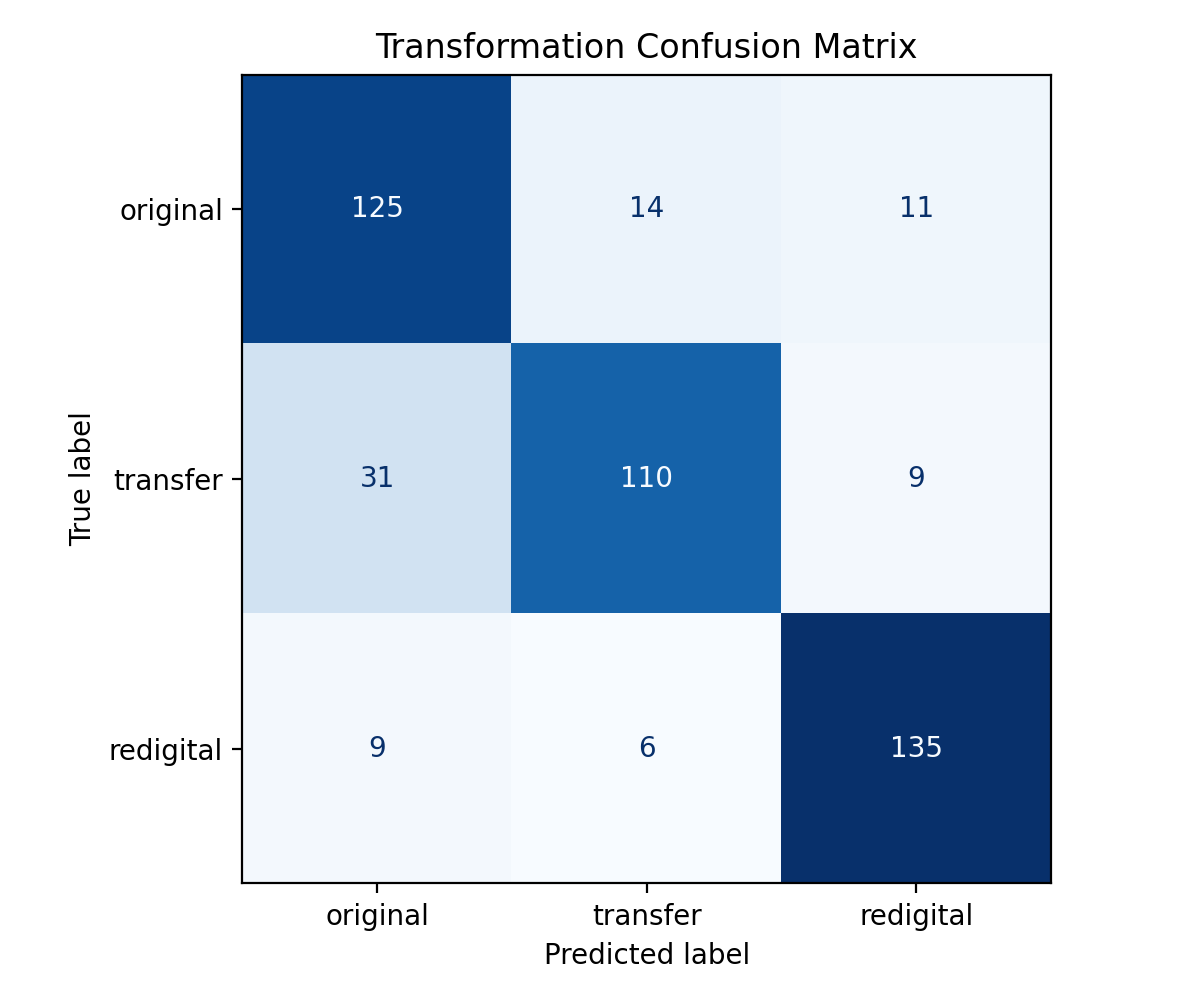

In [ ]:
show_evaluation_outputs("results/rgb_transform")

## RGB Multi-task baseline - manual weights 1.0 / 1.0

This is the standard multi-task baseline.

The model uses a shared RGB backbone and two independent classification heads:

- one head predicts the real/fake label;
- one head predicts the transformation label.

The total loss is computed as:

**L = 1.0 × L_fake + 1.0 × L_transform**

This setting gives equal importance to both tasks.

In [ ]:
# Train the joint RGB multi-task baseline with weights 1 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_1_1.pt

Selected task: multitask
Using device: cuda

Epoch 1/20
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:09<00:00,  1.52it/s]
Train: {'loss': 1.3562386678514027, 'fake_acc': 0.861904761904762, 'transform_acc': 0.43238095238095237}
Val:   {'loss': 1.0541286778450012, 'fake_acc': 0.8822222222222222, 'transform_acc': 0.6222222222222222}
Val score: 0.7522
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_1.pt

Epoch 2/20
Training: 100% 66/66 [00:41<00:00,  1.58it/s]
Validation: 100% 15/15 [00:09<00:00,  1.52it/s]
Train: {'loss': 0.7768587164084116, 'fake_acc': 0.9766666666666667, 'transform_acc': 0.6585714285714286}
Val:   {'loss': 1.012759114238951, 'fake_acc': 0.9155555555555556, 'transform_acc': 0.6644444444444444}
Val score: 0.7900
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_1.pt

Epoch 3/20
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:10<00:00,  1.39it/s]
Train: {'

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 1 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_1.pt \
  --output_dir results/rgb_multitask_1_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9156
Fake F1 macro:        0.9154

Fake accuracy by transformation:
  original: 0.9067
  transfer: 0.9200
  redigital: 0.9200
Transform accuracy:   0.7933
Transform F1 macro:   0.7902

Saved results in:
results/rgb_multitask_1_1


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9156
1,fake_f1_macro,-,0.9154
2,fake_accuracy_by_transform,original,0.9067
3,fake_accuracy_by_transform,transfer,0.9200
4,fake_accuracy_by_transform,redigital,0.9200
5,transform_accuracy,-,0.7933
6,transform_f1_macro,-,0.7902



Real/Fake confusion matrix


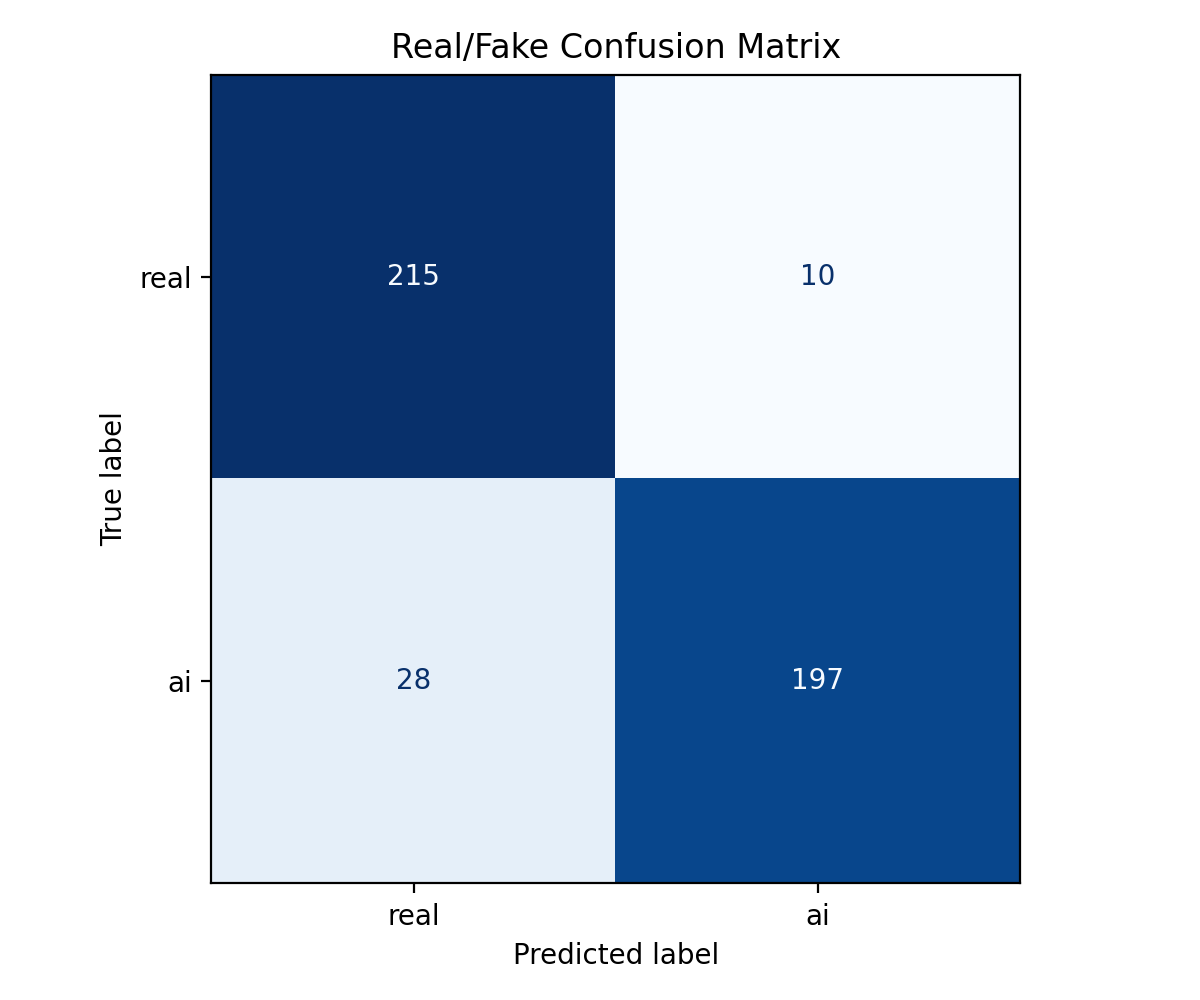


Transformation confusion matrix


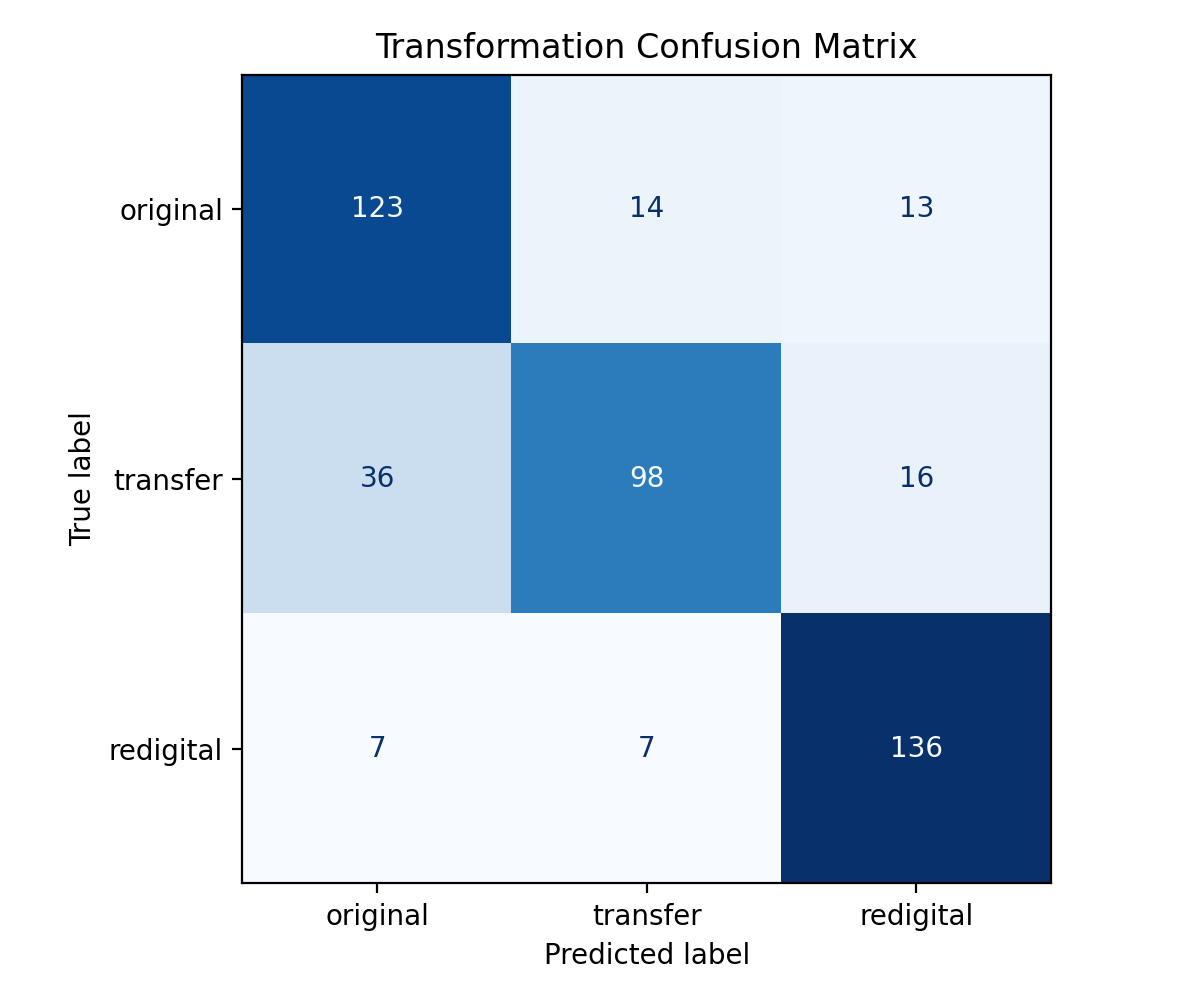

In [ ]:
show_evaluation_outputs("results/rgb_multitask_1_1")

## RGB Multi-task baseline - manual weights 1.0 / 2.0

In this experiment, the transformation loss receives a higher weight than the real/fake loss:

**L = 1.0 × L_fake + 2.0 × L_transform**

The goal is to test whether forcing the model to focus more on transformation recognition also improves real/fake detection.

In [ ]:
# Train the joint RGB multi-task baseline with weights 1 2.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 2.0 \
  --checkpoint_name best_rgb_multitask_1_2.pt

Selected task: multitask
Using device: cuda

Epoch 1/20
Training: 100% 66/66 [00:42<00:00,  1.56it/s]
Validation: 100% 15/15 [00:11<00:00,  1.34it/s]
Train: {'loss': 2.4739467634473526, 'fake_acc': 0.84, 'transform_acc': 0.45380952380952383}
Val:   {'loss': 1.7994067917929755, 'fake_acc': 0.9266666666666666, 'transform_acc': 0.6333333333333333}
Val score: 0.7800
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_2.pt

Epoch 2/20
Training: 100% 66/66 [00:41<00:00,  1.60it/s]
Validation: 100% 15/15 [00:10<00:00,  1.37it/s]
Train: {'loss': 1.4595429851895287, 'fake_acc': 0.9533333333333334, 'transform_acc': 0.680952380952381}
Val:   {'loss': 1.5462102137671576, 'fake_acc': 0.9088888888888889, 'transform_acc': 0.7111111111111111}
Val score: 0.8100
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_2.pt

Epoch 3/20
Training: 100% 66/66 [00:40<00:00,  1.61it/s]
Validation: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {'loss': 1.0877

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 1 2.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_2.pt \
  --output_dir results/rgb_multitask_1_2 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9178
Fake F1 macro:        0.9176

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9133
  redigital: 0.9067
Transform accuracy:   0.8200
Transform F1 macro:   0.8194

Saved results in:
results/rgb_multitask_1_2


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9178
1,fake_f1_macro,-,0.9176
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9133
4,fake_accuracy_by_transform,redigital,0.9067
5,transform_accuracy,-,0.8200
6,transform_f1_macro,-,0.8194



Real/Fake confusion matrix


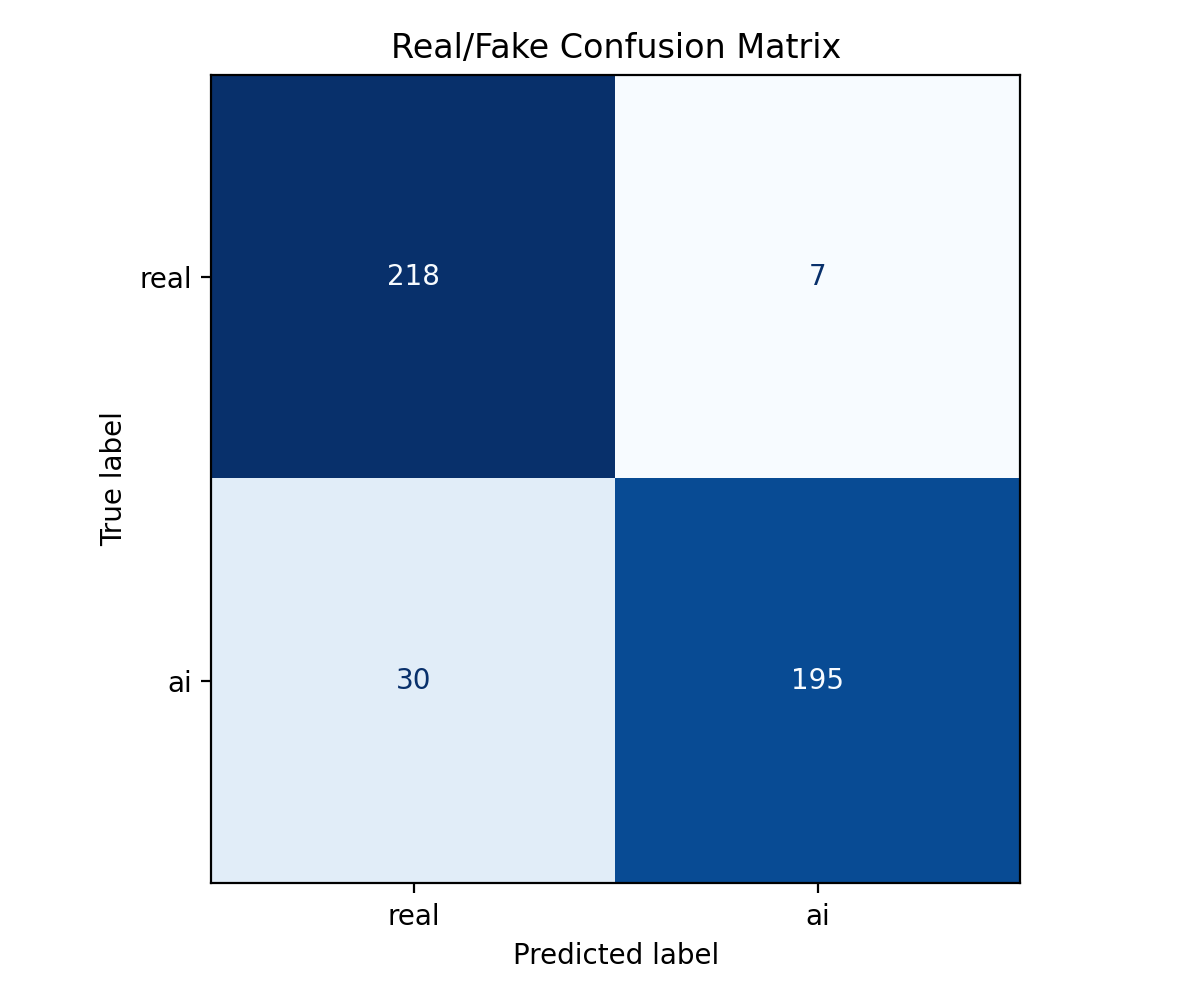


Transformation confusion matrix


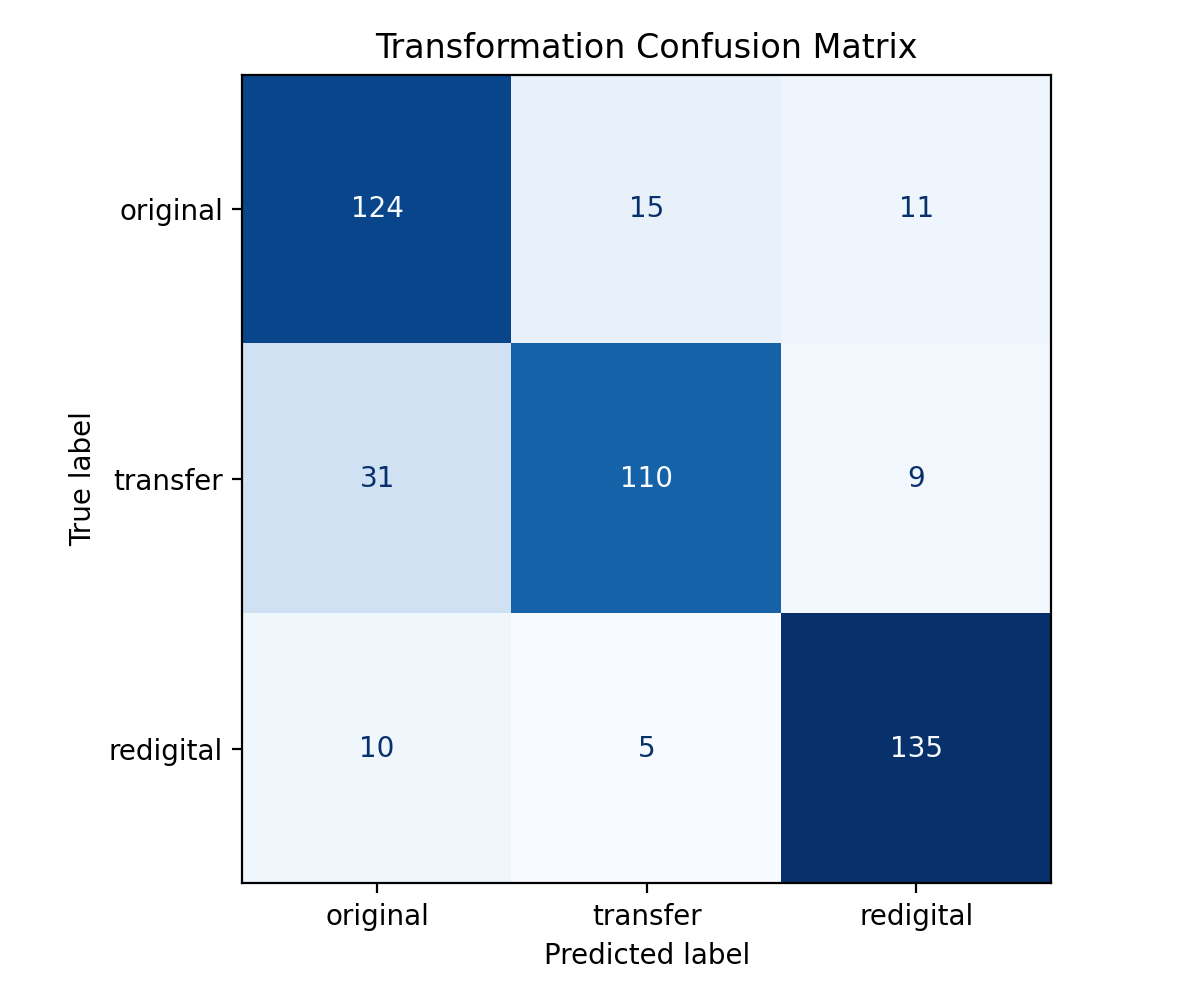

In [ ]:
show_evaluation_outputs("results/rgb_multitask_1_2")

## RGB Multi-task baseline - manual weights 1.0 / 2.0

In this experiment, the real/fake loss receives a higher weight than the transformation loss:

**L = 2.0 × L_fake + 1.0 × L_transform**

This setting prioritizes the main forensic task while still keeping transformation classification as an auxiliary task.

In [ ]:
# Train the joint RGB multi-task baseline with weights 2 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 2.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_2_1.pt

Selected task: multitask
Using device: cuda

Epoch 1/20
Training: 100% 66/66 [00:40<00:00,  1.63it/s]
Validation: 100% 15/15 [00:11<00:00,  1.36it/s]
Train: {'loss': 1.6508464658828008, 'fake_acc': 0.8761904761904762, 'transform_acc': 0.41619047619047617}
Val:   {'loss': 1.4317660586039225, 'fake_acc': 0.9133333333333333, 'transform_acc': 0.5444444444444444}
Val score: 0.7289
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_2_1.pt

Epoch 2/20
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:10<00:00,  1.39it/s]
Train: {'loss': 0.8890702789170402, 'fake_acc': 0.9842857142857143, 'transform_acc': 0.5966666666666667}
Val:   {'loss': 1.3870601889822218, 'fake_acc': 0.9244444444444444, 'transform_acc': 0.5711111111111111}
Val score: 0.7478
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_2_1.pt

Epoch 3/20
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: 

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 2 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_2_1.pt \
  --output_dir results/rgb_multitask_2_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9244
Fake F1 macro:        0.9244

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9267
  redigital: 0.9133
Transform accuracy:   0.8156
Transform F1 macro:   0.8153

Saved results in:
results/rgb_multitask_2_1


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9244
1,fake_f1_macro,-,0.9244
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9267
4,fake_accuracy_by_transform,redigital,0.9133
5,transform_accuracy,-,0.8156
6,transform_f1_macro,-,0.8153



Real/Fake confusion matrix


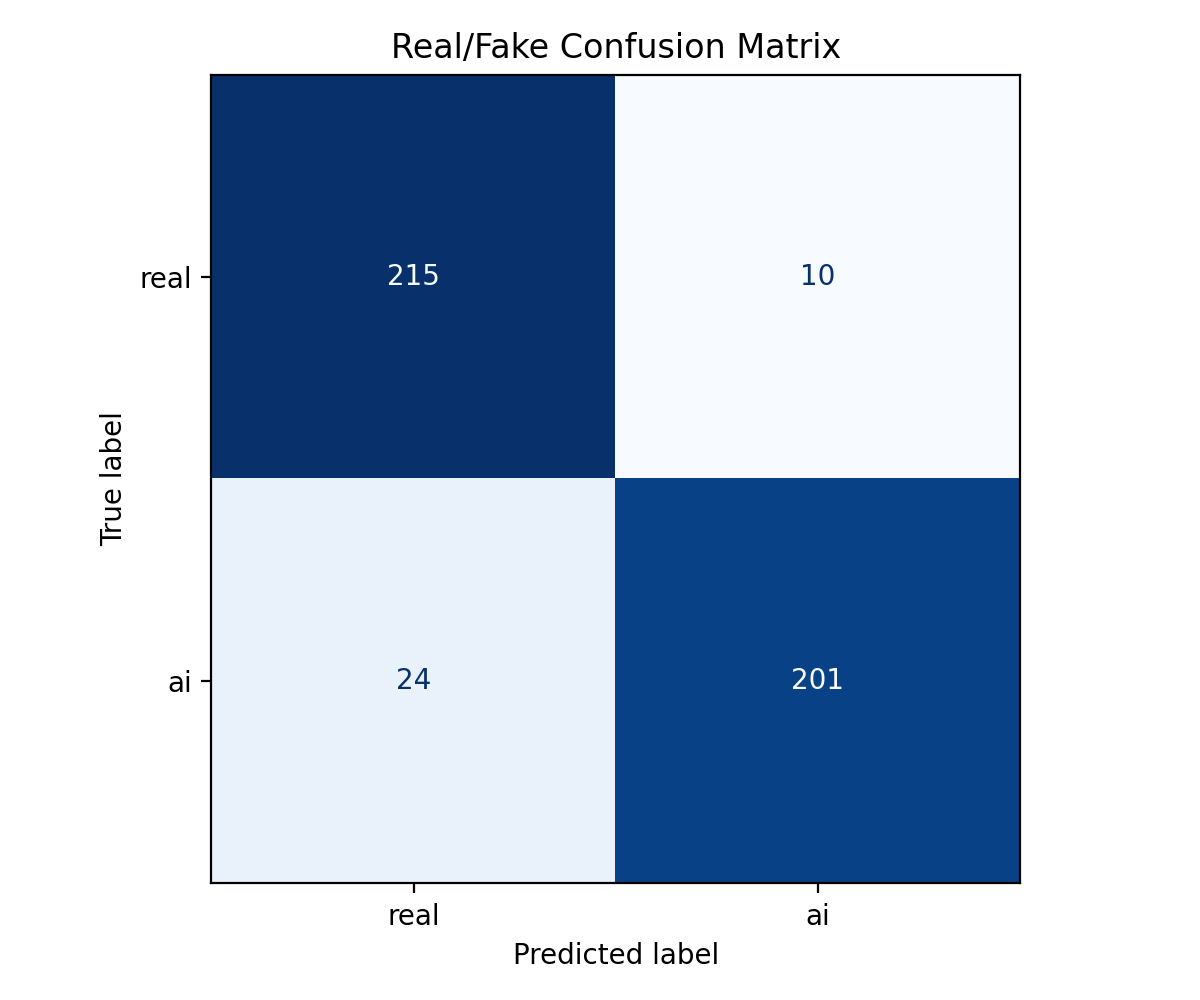


Transformation confusion matrix


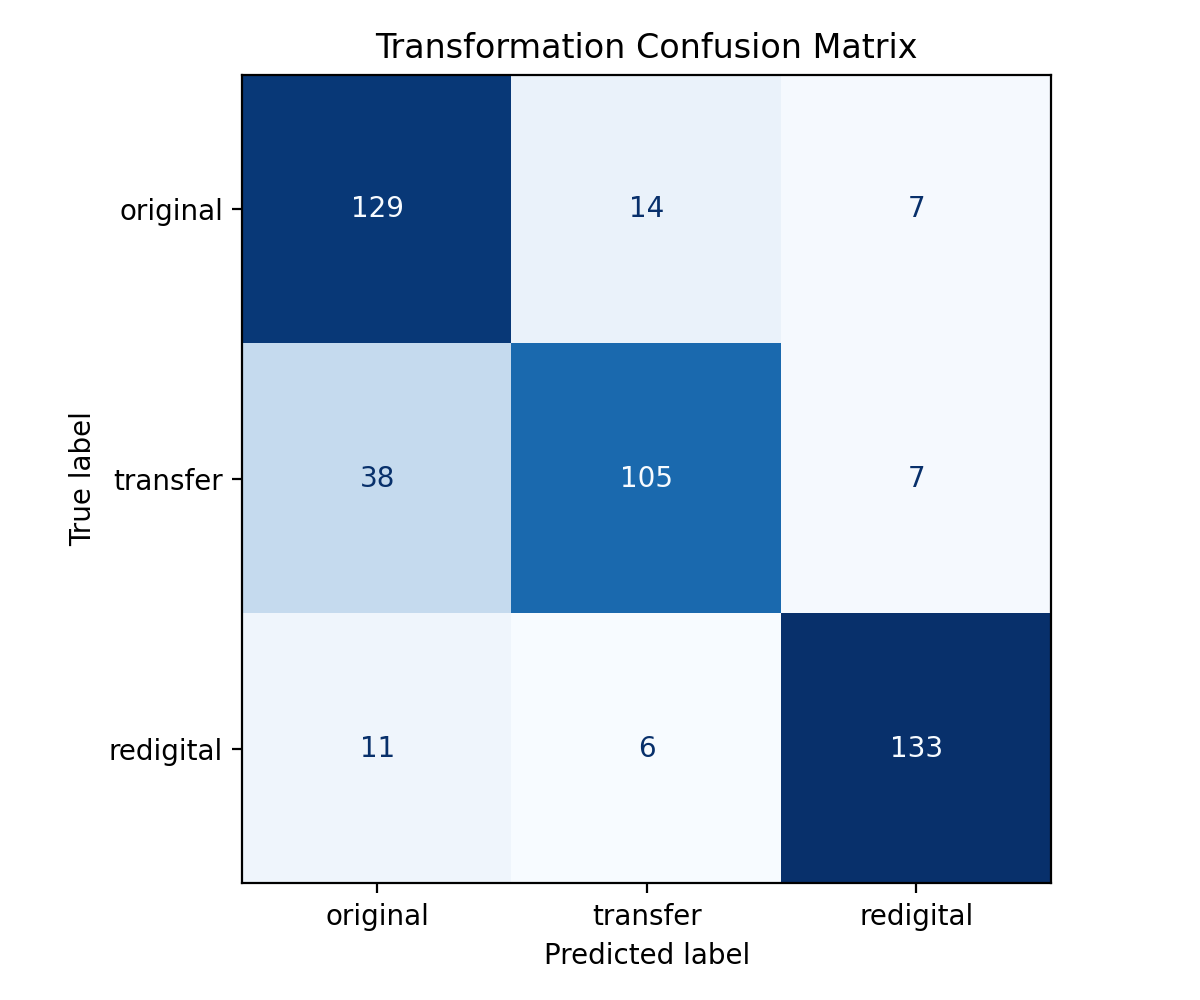

In [ ]:
show_evaluation_outputs("results/rgb_multitask_2_1")

## RGB Multi-task baseline - Learned Uncertainty Weighting

This experiment replaces manually selected loss weights with learned uncertainty-based weights.

Instead of fixing the relative importance of the two tasks before training, the model learns how much each task should contribute to the total loss.

This is useful because the two tasks may have different difficulty levels. If one task is noisier or harder, the learned weighting mechanism can reduce its dominance and make the multi-task optimization more balanced.

In [ ]:
# Train the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/train_RGB.py \
  --task multitask \
  --loss_weighting learned \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_multitask_learned_weights.pt

Selected task: multitask
Using device: cuda

Epoch 1/20
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.43it/s]
Train: {'loss': 1.3669624349049159, 'fake_acc': 0.8733333333333333, 'transform_acc': 0.4204761904761905, 'weight_fake': 1.0034713058760671, 'weight_transform': 0.9975796612826261}
Val:   {'loss': 1.0615184958775838, 'fake_acc': 0.9177777777777778, 'transform_acc': 0.5911111111111111, 'weight_fake': 1.0072448253631592, 'weight_transform': 0.9960739016532898}
Learned loss weights (train): fake=1.0035, transform=0.9976
Learned loss weights (val):   fake=1.0072, transform=0.9961
Val score: 0.7544
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_learned_weights.pt

Epoch 2/20
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 0.7580697363898867, 'fake_acc': 0.9757142857142858, 'transform_acc': 0.6557142857142857, 'weight_fake': 1.0109984224492854, 'weight

In [ ]:
# Evaluate the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_learned_weights.pt \
  --output_dir results/rgb_multitask_learned_weights \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9089
Fake F1 macro:        0.9088

Fake accuracy by transformation:
  original: 0.9000
  transfer: 0.9133
  redigital: 0.9133
Transform accuracy:   0.8133
Transform F1 macro:   0.8133

Saved results in:
results/rgb_multitask_learned_weights


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9089
1,fake_f1_macro,-,0.9088
2,fake_accuracy_by_transform,original,0.9000
3,fake_accuracy_by_transform,transfer,0.9133
4,fake_accuracy_by_transform,redigital,0.9133
5,transform_accuracy,-,0.8133
6,transform_f1_macro,-,0.8133



Real/Fake confusion matrix


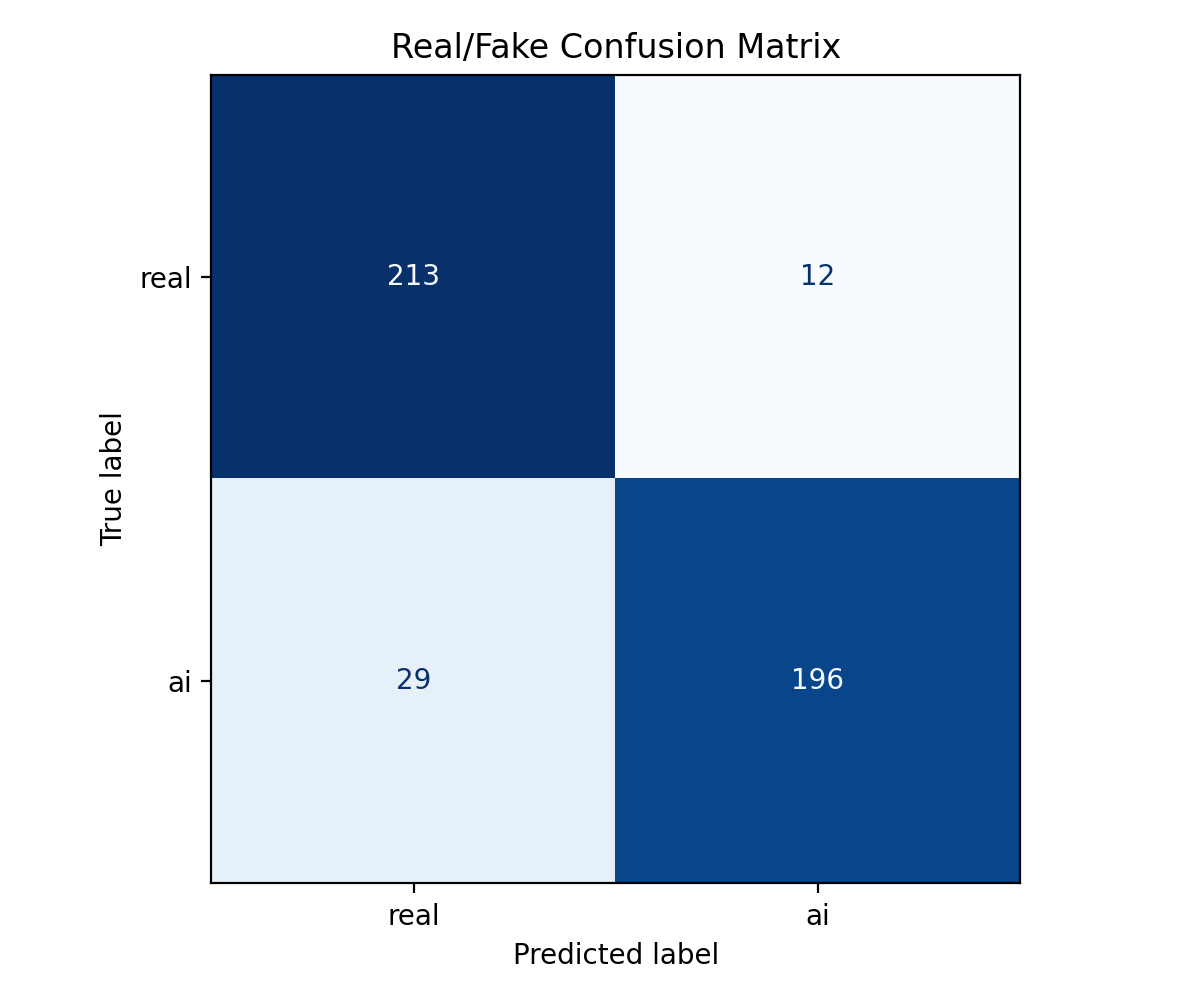


Transformation confusion matrix


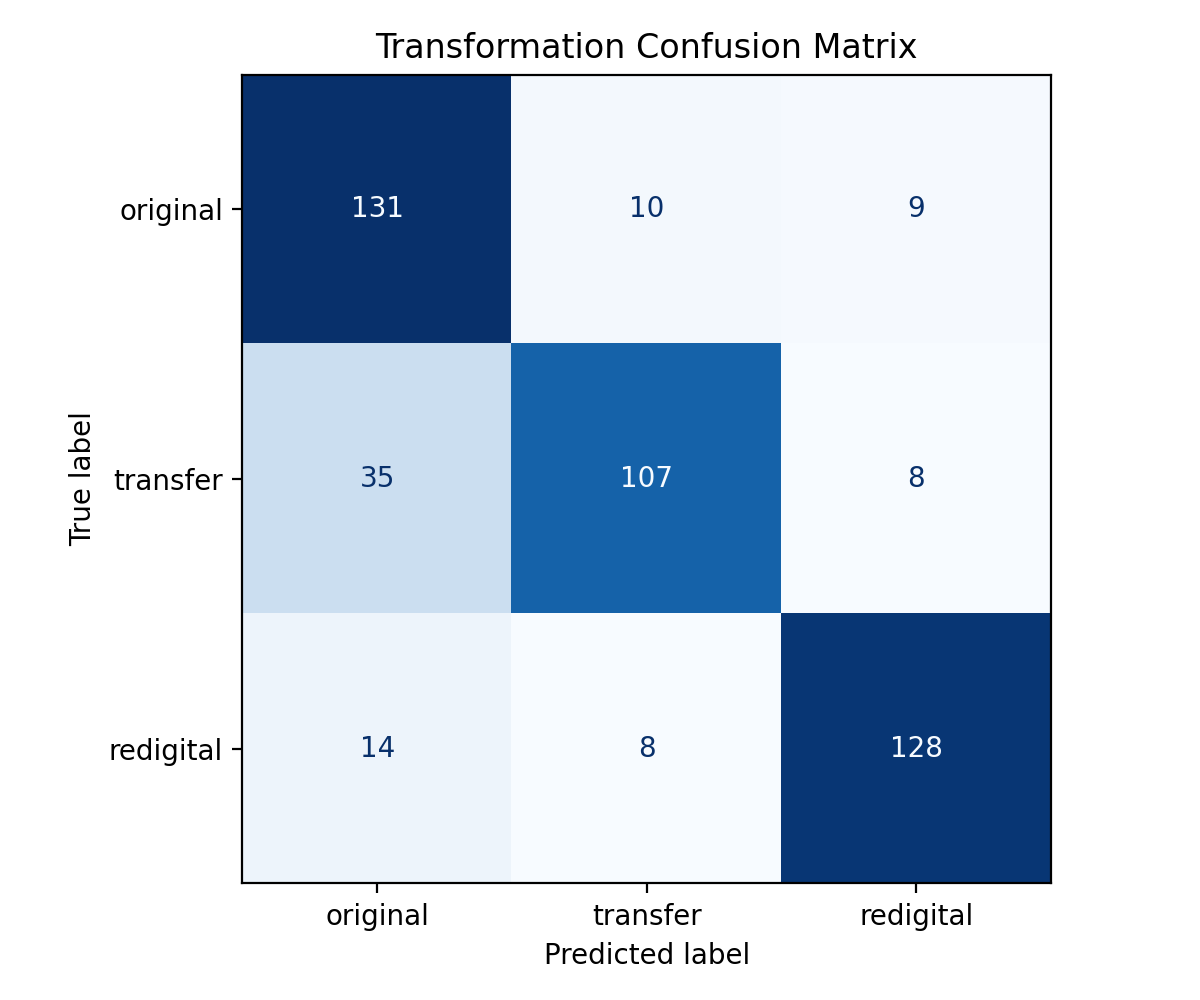

In [ ]:
show_evaluation_outputs("results/rgb_multitask_learned_weights")

## Results Comparison and Ablation Study

This section compares the RGB baselines and the RGB multi-task models.

The objective is to understand whether the transformation task helps the real/fake detector learn more robust features, or whether the two objectives interfere with each other during training.

We also compare different loss-weighting strategies, since changing the relative importance of the two losses can affect the balance between real/fake accuracy and transformation accuracy.

Finally, we report real/fake accuracy by transformation type to check whether the model remains reliable on original, transmitted, and re-digitized images.

In [ ]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}

rows = []

for model_name, metrics_path in results.items():
    metrics_path = Path(metrics_path)

    if not metrics_path.exists():
        print(f"Missing file: {metrics_path}")
        continue

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    rows.append({
        "model": model_name,
        "fake_accuracy": metrics.get("fake_accuracy"),
        "fake_f1_macro": metrics.get("fake_f1_macro"),
        "transform_accuracy": metrics.get("transform_accuracy"),
        "transform_f1_macro": metrics.get("transform_f1_macro"),
        "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
        "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
        "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.sort_values(
    by=["fake_accuracy", "transform_accuracy"],
    ascending=False
)

,model,fake_accuracy,fake_f1_macro,transform_accuracy,transform_f1_macro,fake_acc_original,fake_acc_transfer,fake_acc_redigital
4,RGB multitask 2-1,0.924444,0.924371,0.815556,0.815282,0.933333,0.926667,0.913333
0,RGB fake-only,0.922222,0.922111,NaN,NaN,0.920000,0.933333,0.913333
3,RGB multitask 1-2,0.917778,0.917562,0.820000,0.819421,0.933333,0.913333,0.906667
2,RGB multitask 1-1,0.915556,0.915420,0.793333,0.790199,0.906667,0.920000,0.920000
5,RGB multitask learned,0.908889,0.908759,0.813333,0.813306,0.900000,0.913333,0.913333
1,RGB transform-only,NaN,NaN,0.822222,0.821537,NaN,NaN,NaN


### Global accuracy comparison

The following plot compares the main accuracy scores across RGB experiments.

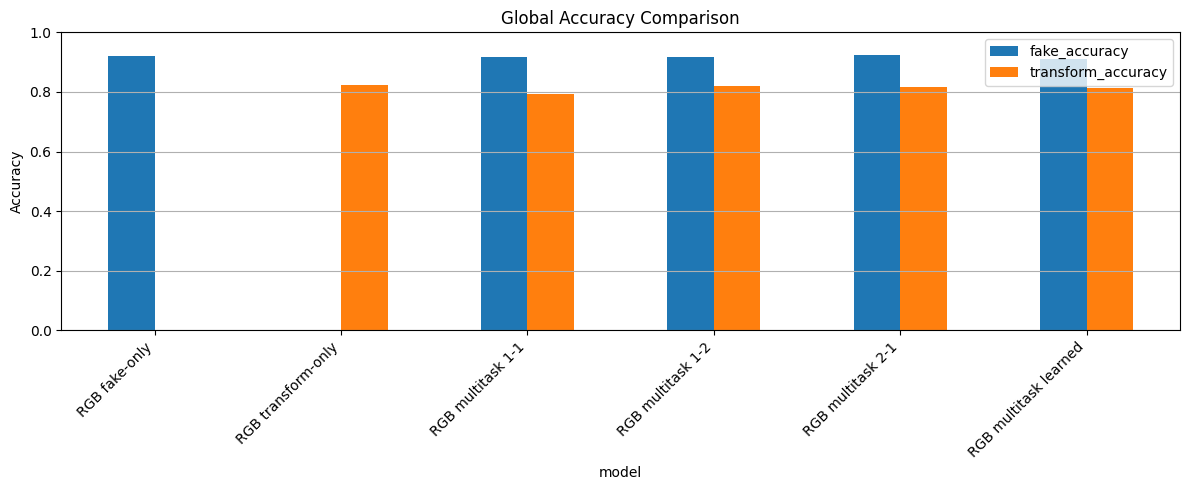

In [ ]:
# Global Accuracy Comparison

plot_df = comparison_df.set_index("model")

plot_df[["fake_accuracy", "transform_accuracy"]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Global Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Real/Fake accuracy by transformation type

This analysis breaks down real/fake detection accuracy across transformation categories.

This is important because the main challenge of the project is not only detecting AI-generated images in clean conditions, but also maintaining robustness after real-world post-processing.

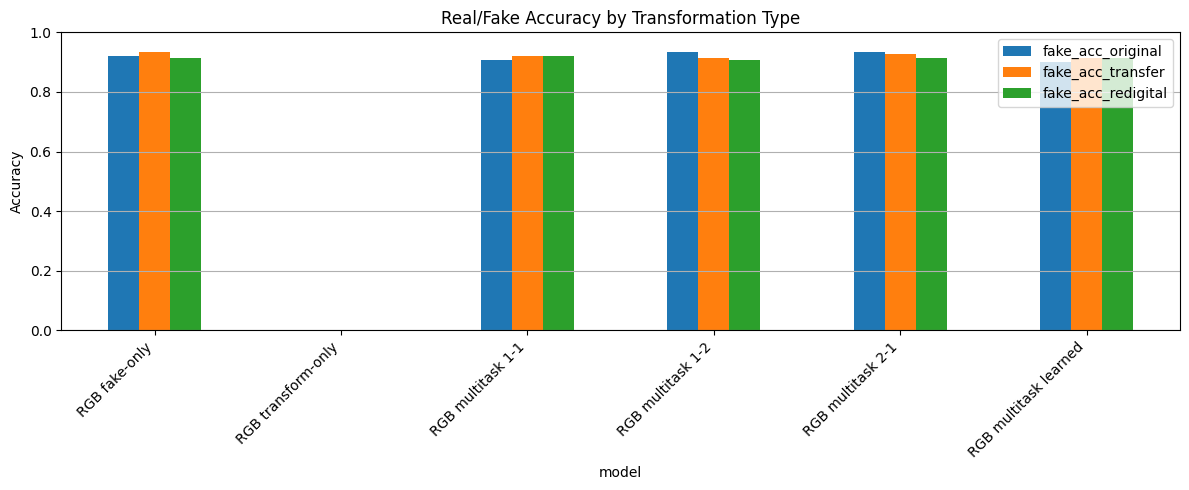

In [ ]:
# Real/Fake Accuracy by Transformation Type
plot_df[[
    "fake_acc_original",
    "fake_acc_transfer",
    "fake_acc_redigital",
]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Real/Fake Accuracy by Transformation Type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#Frequency

GANs genereate periodic artifacts, invisibles in RGB, but that can be detect in frequency domain.
Is used FFT on the amplitude log-spectrum.

lambda_fake=1.0 and lambda_transform=2.0 in order to improve trasformation evaluetion, that is the critical aspect in RGB.


**TRAIN**

In [29]:
# Frequency multi-task using weights 1.0 / 1.0
!python src/train_freq.py \
  --train_csv        {TRAIN_CSV} \
  --val_csv          {VAL_CSV} \
  --image_root       {IMAGE_ROOT} \
  --epochs           {EPOCHS} \
  --batch_size       {BATCH_SIZE} \
  --image_size       {IMAGE_SIZE} \
  --num_workers      {NUM_WORKERS} \
  --lambda_fake      1.0 \
  --lambda_transform 2.0 \
  --checkpoint_name  best_freq_multitask_1_1.pt

Using device: cuda

Epoch 1/20
Training freq: 100% 66/66 [00:44<00:00,  1.49it/s]
Validation freq: 100% 15/15 [00:11<00:00,  1.31it/s]
Train: {'loss': 2.51776993842352, 'fake_acc': 0.8114285714285714, 'transform_acc': 0.40904761904761905}
Val:   {'loss': 1.9931508082813687, 'fake_acc': 0.8822222222222222, 'transform_acc': 0.5577777777777778}
Val score: 0.7200
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_freq_multitask_1_1.pt

Epoch 2/20
Training freq: 100% 66/66 [00:44<00:00,  1.48it/s]
Validation freq: 100% 15/15 [00:10<00:00,  1.39it/s]
Train: {'loss': 1.6240909126826695, 'fake_acc': 0.9366666666666666, 'transform_acc': 0.6247619047619047}
Val:   {'loss': 1.8805862330728107, 'fake_acc': 0.8955555555555555, 'transform_acc': 0.6555555555555556}
Val score: 0.7756
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_freq_multitask_1_1.pt

Epoch 3/20
Training freq: 100% 66/66 [00:44<00:00,  1.48it/s]
Validation freq: 100% 15/15 [00:11<00:00,  1.30it/s]
Tr

**EVALUATE**

In [30]:
!python src/evaluate_freq.py \
  --csv_path    {TEST_CSV} \
  --image_root  {IMAGE_ROOT} \
  --checkpoint  checkpoints/best_freq_multitask_1_1.pt \
  --output_dir  results/freq_multitask_1_1 \
  --batch_size  {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Using device: cuda

Evaluation results — Frequency model
Fake accuracy:        0.9267
Fake F1 macro:        0.9266
Transform accuracy:   0.8378
Transform F1 macro:   0.8374

Fake accuracy by transformation:
  original: 0.9267
  transfer: 0.9467
  redigital: 0.9067

Saved results in: results/freq_multitask_1_1


**RESULTS**

Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9267
1,fake_f1_macro,-,0.9266
2,transform_accuracy,-,0.8378
3,transform_f1_macro,-,0.8374
4,fake_accuracy_by_transform,original,0.9267
5,fake_accuracy_by_transform,transfer,0.9467
6,fake_accuracy_by_transform,redigital,0.9067



Real/Fake confusion matrix


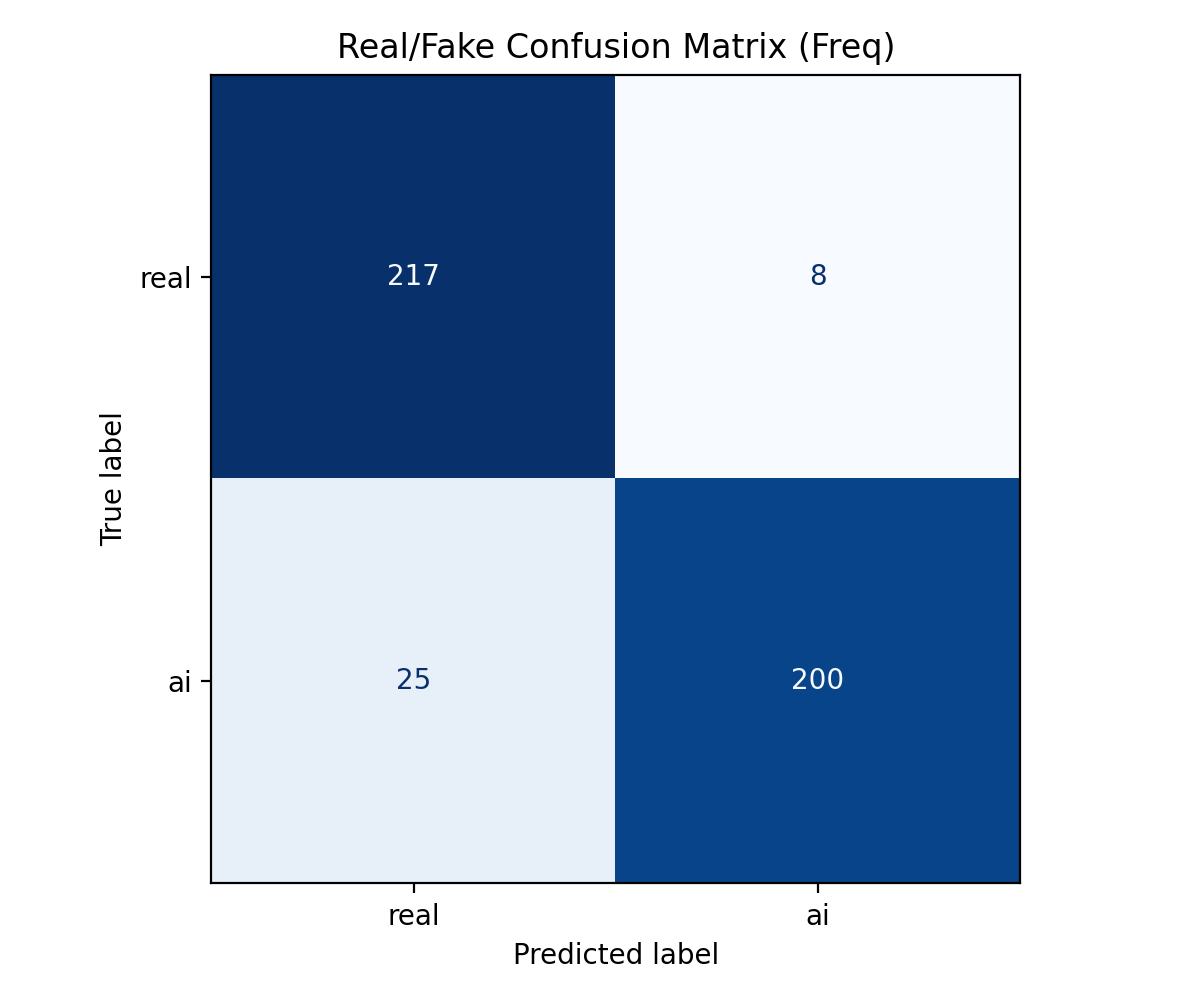


Transformation confusion matrix


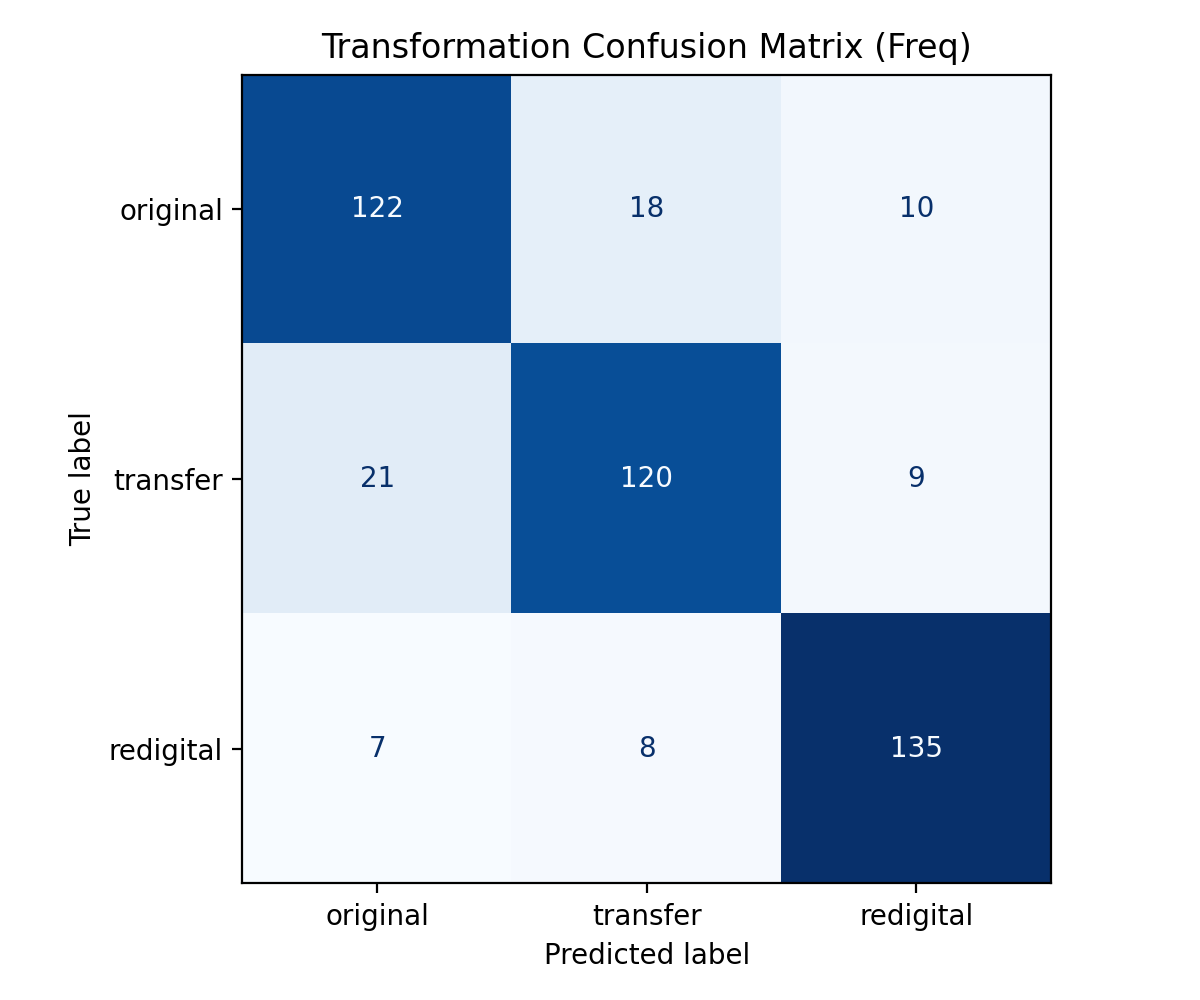

In [31]:
show_evaluation_outputs("results/freq_multitask_1_1")

**COMPARISON**

In [34]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}
results["Freq multitask 1-1"] = "results/freq_multitask_1_1/metrics.json"

**Different training Cosine scheduler with warm-up and Learned uncertainty weighting**

In [ ]:
!python src/FrequencyAugumented.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs 20 \
  --batch_size {BATCH_SIZE} \
  --num_workers {NUM_WORKERS} \
  --scheduler cosine \
  --warmup_epochs 2 \
  --loss_weighting learned \
  --checkpoint_name best_freq_learned_cosine.pt

Using device: cuda
Scheduler:    cosine
Loss weights: learned
Learned uncertainty weighting enabled.
  Initial log_var_fake:      0.0000
  Initial log_var_transform: 0.0000

Epoch 1/20
Training freq: 100% 66/66 [00:44<00:00,  1.49it/s]
Validation freq: 100% 15/15 [00:10<00:00,  1.45it/s]
Train: {'loss': 1.7724536012467884, 'fake_acc': 0.611904761904762, 'transform_acc': 0.33, 'w_fake': 1.00033218571634, 'w_transform': 0.9996847907702128}
Val:   {'loss': 1.7164251110288833, 'fake_acc': 0.7755555555555556, 'transform_acc': 0.35555555555555557}
Val score:     0.5656
Learning rate: 0.000011
Learned w_fake: 1.0007  |  w_transform: 0.9994
Saved best checkpoint → checkpoints/best_freq_learned_cosine.pt

Epoch 2/20
Training freq: 100% 66/66 [00:43<00:00,  1.51it/s]
Validation freq: 100% 15/15 [00:11<00:00,  1.33it/s]
Train: {'loss': 1.6649071793329149, 'fake_acc': 0.8138095238095238, 'transform_acc': 0.37142857142857144, 'w_fake': 1.0010749878305378, 'w_transform': 0.9990541022835355}
Val:   {

**Evaluation**

In [35]:
!python src/evaluate_freq.py \
  --csv_path    {TEST_CSV} \
  --image_root  {IMAGE_ROOT} \
  --checkpoint  checkpoints/best_freq_multitask_1_1.pt \
  --output_dir  results/freq_multitask_1_1 \
  --batch_size  {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Using device: cuda

Evaluation results — Frequency model
Fake accuracy:        0.9267
Fake F1 macro:        0.9266
Transform accuracy:   0.8378
Transform F1 macro:   0.8374

Fake accuracy by transformation:
  original: 0.9267
  transfer: 0.9467
  redigital: 0.9067

Saved results in: results/freq_multitask_1_1


**Results**

**Comparison**

##VIT

**TRAIN**

In [ ]:
!python src/train_vit.py \
  --train_csv  {TRAIN_CSV} \
  --val_csv    {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs     {EPOCHS} \
  --batch_size 16 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_vit_multitask_1_1.pt

**Evalutation**

In [ ]:
!python src/evaluate_vit.py \
  --csv_path   {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_vit_multitask_1_1.pt \
  --output_dir results/vit_multitask_1_1 \
  --batch_size 16 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

**Comparison**

In [ ]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}
results["ViT multitask 1-1"] = "results/vit_multitask_1_1/metrics.json"

#DEPTH

In [ ]:
!find /content -name "real_006970.jpg"

##Depth map generation

###first small debug

In [ ]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV}\
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small \
  --max_images 5

###full depth map generation

In [ ]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small

In [ ]:
from pathlib import Path

DRIVE_DEPTH_ROOT = Path("/content/drive/MyDrive/CV_Project/depth_maps")
LOCAL_DEPTH_ROOT = Path("/content/depth_maps")
DEPTH_ROOT = str(LOCAL_DEPTH_ROOT)

DRIVE_DEPTH_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_DEPTH_ROOT.mkdir(parents=True, exist_ok=True)

# Count existing depth maps on Drive
drive_depth_files = list(DRIVE_DEPTH_ROOT.rglob("*.npy"))

print(f"Depth maps found on Drive: {len(drive_depth_files)}")

if len(drive_depth_files) == 0:
    print("No depth maps found on Drive. Generating them once and saving directly to Drive...")

    !python src/generate_depth_map.py \
      --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV} \
      --image_root {IMAGE_ROOT} \
      --depth_root "{DRIVE_DEPTH_ROOT}" \
      --model_type MiDaS_small

else:
    print("Depth maps already exist on Drive. No need to regenerate them.")

# Copy depth maps from Drive to local /content for faster training/evaluation
print("Copying depth maps from Drive to local /content...")
!rsync -a --info=progress2 "{DRIVE_DEPTH_ROOT}/" "{LOCAL_DEPTH_ROOT}/"

DEPTH_ROOT = str(LOCAL_DEPTH_ROOT)

print("Local DEPTH_ROOT:", DEPTH_ROOT)
print("Some local depth maps:")
!find "{DEPTH_ROOT}" -type f -name "*.npy" | head

##copy of depth maph in local so colab doesn't need to go on drive every time

In [ ]:
DRIVE_DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"
LOCAL_DEPTH_ROOT = "/content/depth_maps"

!mkdir -p "{LOCAL_DEPTH_ROOT}"
!rsync -a --info=progress2 "{DRIVE_DEPTH_ROOT}/" "{LOCAL_DEPTH_ROOT}/"

DEPTH_ROOT = LOCAL_DEPTH_ROOT

print("Depth maps will be loaded from:", DEPTH_ROOT)

##First try with depth only

In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting \
  --no_edge

The edge-consistency branch introduces additional geometric information, but also increases model complexity. This leads to mild overfitting and a small decrease in real/fake validation accuracy, although transformation classification slightly improves.
We should use only depth without edge

##Evaluate RGB+Depth no edge

saves on drive not only local

In [ ]:
DRIVE_CKPT_ROOT = "/content/drive/MyDrive/CV_Project/checkpoints"

!mkdir -p "{DRIVE_CKPT_ROOT}"
!cp /content/REPO/checkpoints/*.pt "{DRIVE_CKPT_ROOT}/"

!ls "{DRIVE_CKPT_ROOT}"

puts again in local

In [ ]:
DRIVE_CKPT_ROOT = "/content/drive/MyDrive/CV_Project/checkpoints"
LOCAL_CKPT_ROOT = "/content/REPO/checkpoints"

!mkdir -p "{LOCAL_CKPT_ROOT}"
!cp "{DRIVE_CKPT_ROOT}"/*.pt "{LOCAL_CKPT_ROOT}/"

!ls "{LOCAL_CKPT_ROOT}"

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/depth_only \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge

In [ ]:
show_evaluation_outputs("results/depth_only")

##Second try with also edge consistency

In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_edge_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

#Evaluate RGB+Depth+edge

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/depth_edge \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

In [ ]:
show_evaluation_outputs("results/depth_edge")

##grad-cam

real

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 0 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 1 \
  --shuffle

transform

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 0 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 1 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 2 \
  --shuffle

In [ ]:
from IPython.display import Image, display
from pathlib import Path

gradcam_dir = Path("results/gradcam_depth")

for img_path in sorted(gradcam_dir.glob("*.png")):
    print(img_path.name)
    display(Image(filename=str(img_path)))

#comparison depth with depth+edge

In [ ]:


import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def build_comparison_df(results_dict):
    rows = []

    for model_name, metrics_path in results_dict.items():
        metrics_path = Path(metrics_path)

        if not metrics_path.exists():
            print(f"Missing file: {metrics_path}")
            continue

        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        rows.append({
            "model": model_name,
            "fake_accuracy": metrics.get("fake_accuracy"),
            "fake_f1_macro": metrics.get("fake_f1_macro"),
            "transform_accuracy": metrics.get("transform_accuracy"),
            "transform_f1_macro": metrics.get("transform_f1_macro"),
            "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
            "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
            "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
        })

    comparison_df = pd.DataFrame(rows)

    if len(comparison_df) > 0:
        comparison_df = comparison_df.sort_values(
            by=["fake_accuracy", "transform_accuracy"],
            ascending=False,
        )

    return comparison_df


def plot_global_accuracy(comparison_df, title):
    plot_df = comparison_df.set_index("model")

    plot_df[["fake_accuracy", "transform_accuracy"]].plot(
        kind="bar",
        figsize=(12, 5),
    )

    plt.title(title)
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_fake_accuracy_by_transformation(comparison_df, title):
    plot_df = comparison_df.set_index("model")

    plot_df[[
        "fake_acc_original",
        "fake_acc_transfer",
        "fake_acc_redigital",
    ]].plot(
        kind="bar",
        figsize=(12, 5),
    )

    plt.title(title)
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

In [ ]:
depth_results = {
    "RGB + Depth": "results/depth_only/metrics.json",
    "RGB + Depth + Edge": "results/depth_edge/metrics.json",
}

depth_comparison_df = build_comparison_df(depth_results)

depth_comparison_df


plot_global_accuracy(
    depth_comparison_df,
    "Depth Ablation: Global Accuracy Comparison"
)



plot_fake_accuracy_by_transformation(
    depth_comparison_df,
    "Depth Ablation: Real/Fake Accuracy by Transformation Type"
)




#DEPTH+FREQUENCY

In [ ]:
print(EPOCHS)
print(type(EPOCHS))

!echo {EPOCHS}

In [ ]:
!python src/train_depth_frequency.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_frequency_uncertainty.pt \
  --checkpoint_dir checkpoints \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

In [ ]:
from pathlib import Path
import shutil

# Permanent Drive folder
DRIVE_CKPT_ROOT = Path("/content/drive/MyDrive/CV_Project/checkpoints")

# Local temporary Colab folder
LOCAL_CKPT_ROOT = Path("/content/REPO/checkpoints")

# Safety checks
if not Path("/content/drive/MyDrive").exists():
    raise RuntimeError("Drive is not mounted. Run drive.mount('/content/drive') first.")

if not LOCAL_CKPT_ROOT.exists():
    raise RuntimeError(f"Local checkpoint folder not found: {LOCAL_CKPT_ROOT}")

# Create permanent folder on Drive
DRIVE_CKPT_ROOT.mkdir(parents=True, exist_ok=True)

# Copy every .pt checkpoint to Drive
checkpoint_files = list(LOCAL_CKPT_ROOT.glob("*.pt"))

if len(checkpoint_files) == 0:
    print("No .pt checkpoint files found in:", LOCAL_CKPT_ROOT)
else:
    for checkpoint_path in checkpoint_files:
        destination = DRIVE_CKPT_ROOT / checkpoint_path.name
        shutil.copy2("/content/REPO/checkpoints/best_depth_frequency_uncertainty.pt/best_depth_frequency_uncertainty.pt", destination)
        print(f"Saved: {checkpoint_path.name} -> {destination}")

print("\nCheckpoints currently saved on Drive:")
for file in sorted(DRIVE_CKPT_ROOT.glob("*.pt")):
    print(file.name)

##evaluate

In [ ]:
from pathlib import Path
import shutil
import time

LOCAL_CKPT_ROOT = Path("/content/REPO/checkpoints")
DRIVE_CKPT_ROOT = Path("/content/drive/MyDrive/CV_Project/checkpoints")

BAD_PATH = LOCAL_CKPT_ROOT / "best_depth_frequency_uncertainty.pt"
FINAL_FILE = LOCAL_CKPT_ROOT / "best_depth_frequency_uncertainty.pt"
DRIVE_FINAL_FILE = DRIVE_CKPT_ROOT / "best_depth_frequency_uncertainty.pt"

DRIVE_CKPT_ROOT.mkdir(parents=True, exist_ok=True)

if not BAD_PATH.exists():
    raise RuntimeError(f"Path not found: {BAD_PATH}")

if BAD_PATH.is_file():
    print("Good news: this is already a file, not a directory.")
    print(BAD_PATH)

elif BAD_PATH.is_dir():
    print("Found wrong directory:", BAD_PATH)

    # 1. Backup the whole wrong folder to Drive before deleting anything.
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    BACKUP_DIR = DRIVE_CKPT_ROOT / f"backup_wrong_checkpoint_folder_{timestamp}"

    shutil.copytree(BAD_PATH, BACKUP_DIR)
    print("Backup of wrong folder saved to Drive:")
    print(BACKUP_DIR)

    # 2. Search for real .pt checkpoint files inside the wrong folder.
    candidates = sorted(
        BAD_PATH.rglob("*.pt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    print("\nCandidate checkpoint files found inside wrong folder:")
    for i, candidate in enumerate(candidates):
        size_mb = candidate.stat().st_size / (1024 * 1024)
        print(f"{i}: {candidate} | {size_mb:.2f} MB")

    if len(candidates) == 0:
        raise RuntimeError(
            "No real .pt file found inside the wrong folder. "
            "Nothing was deleted. Check the backup folder on Drive."
        )

    # 3. Choose the newest .pt file as the real checkpoint.
    chosen_checkpoint = candidates[0]
    print("\nChosen checkpoint:")
    print(chosen_checkpoint)

    # 4. Copy chosen checkpoint to a temporary safe location.
    TEMP_SAFE_FILE = Path("/content/best_depth_frequency_uncertainty_SAFE.pt")
    shutil.copy2(chosen_checkpoint, TEMP_SAFE_FILE)
    print("\nTemporary safe copy created:")
    print(TEMP_SAFE_FILE)

    # 5. Save chosen checkpoint permanently to Drive.
    shutil.copy2(chosen_checkpoint, DRIVE_FINAL_FILE)
    print("\nPermanent checkpoint saved to Drive:")
    print(DRIVE_FINAL_FILE)

    # 6. Remove the wrong directory.
    shutil.rmtree(BAD_PATH)
    print("\nRemoved wrong directory:")
    print(BAD_PATH)

    # 7. Put the real checkpoint file back with the correct name.
    shutil.copy2(TEMP_SAFE_FILE, FINAL_FILE)
    print("\nCorrect checkpoint file restored locally:")
    print(FINAL_FILE)

else:
    raise RuntimeError(f"Unexpected path type: {BAD_PATH}")

print("\nFinal check:")
!ls -lh /content/REPO/checkpoints
print("\nDrive check:")
!ls -lh /content/drive/MyDrive/CV_Project/checkpoints

In [ ]:
!python src/evaluation_depth_frequency.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_uncertainty.pt \
  --output_dir results/depth_frequency_uncertainty \
  --batch_size {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

In [ ]:
show_evaluation_outputs("results/depth_frequency_uncertainty")

##gradcam

In [ ]:
!python src/gradcam_depth_frequency.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 0 \
  --shuffle


In [ ]:
!python src/gradcam_depth_frequency.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 1 \
  --shuffle


In [ ]:
!python src/gradcam_depth_frequency.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 0 \
  --shuffle



In [ ]:
!python src/gradcam_depth_frequency.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 1 \
  --shuffle



In [ ]:
!python src/gradcam_depth_frequency.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 2 \
  --shuffle

In [ ]:
from IPython.display import Image, display
from pathlib import Path

gradcam_dir = Path("results/gradcam_depth_frequency")

for img_path in sorted(gradcam_dir.glob("*.png")):
    print(img_path.name)
    display(Image(filename=str(img_path)))

maybe this saves checkpoint for real

In [ ]:
from pathlib import Path

DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/CV_Project")
DRIVE_CHECKPOINT_DIR = DRIVE_PROJECT_ROOT / "checkpoints"
LOCAL_CHECKPOINT_DIR = Path("/content/REPO/checkpoints")

DRIVE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

!rsync -a --info=progress2 "{LOCAL_CHECKPOINT_DIR}/" "{DRIVE_CHECKPOINT_DIR}/"

print("Saved checkpoints permanently on Drive:")
!find "{DRIVE_CHECKPOINT_DIR}" -type f -name "*.pt" -exec ls -lh {{}} \;

#depth frequency gated

In [ ]:
DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/CV_Project/checkpoints"

In [ ]:
!python src/train_depth_frequency_gated.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_frequency_gated_uncertainty.pt \
  --checkpoint_dir {DRIVE_CHECKPOINT_DIR} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

##evaluation

In [ ]:
!python src/evaluate_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint {DRIVE_CHECKPOINT_DIR}/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/depth_frequency_gated_uncertainty \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

In [ ]:
show_evaluation_outputs("results/depth_frequency_gated_uncertainty")

#comparison depthfrequency and depthfrequency gated

In [ ]:
depth_frequency_results = {
    "RGB + Depth + Frequency + Uncertainty": "results/depth_frequency_uncertainty/metrics.json",
    "RGB + Depth + Frequency Gated + Uncertainty": "results/depth_frequency_gated_uncertainty/metrics.json",
}

depth_frequency_comparison_df = build_comparison_df(depth_frequency_results)

depth_frequency_comparison_df

plot_global_accuracy(
    depth_frequency_comparison_df,
    "Depth + Frequency Ablation: Global Accuracy Comparison"
)


plot_fake_accuracy_by_transformation(
    depth_frequency_comparison_df,
    "Depth + Frequency Ablation: Real/Fake Accuracy by Transformation Type"
)

#tabelle in caso

In [21]:
ABLATION_OUTPUT_DIR = Path("results/ablation_study")
ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

depth_comparison_df.to_csv(
    ABLATION_OUTPUT_DIR / "depth_vs_depth_edge_comparison.csv",
    index=False,
)

depth_frequency_comparison_df.to_csv(
    ABLATION_OUTPUT_DIR / "depth_frequency_simple_vs_gated_comparison.csv",
    index=False,
)

print("Saved ablation tables in:", ABLATION_OUTPUT_DIR)

NameError: name 'depth_comparison_df' is not defined